In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

In [36]:
df = pd.read_csv("creditcard.csv")

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [38]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [39]:
X = df.drop('Class', axis=1).values
y = df['Class'].values

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [50]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

In [51]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([227845, 30]) torch.Size([56962, 30])
torch.Size([227845, 1]) torch.Size([56962, 1])


In [104]:
class FraudClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(30, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32,1)
        )

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.sequential(x)

In [105]:
model = FraudClassifier().to(device)
print(model)

FraudClassifier(
  (sequential): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [106]:
torch.manual_seed(42)

pos_weight = torch.tensor([40.0], dtype=torch.float32).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [107]:
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryF1Score

precision_metric = BinaryPrecision().to(device)
recall_metric = BinaryRecall().to(device)
f1_score_metric = BinaryF1Score().to(device)

torch.manual_seed(42)
train_loss = []
test_losss = []

epochs = 100
for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    loss = loss_fn(y_logits, y_train)
    train_loss.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss   = loss_fn(test_logits, y_test.float())
        test_losss.append(test_loss.item())
        test_preds  = (torch.sigmoid(test_logits) > 0.5).long()

        precision = precision_metric(test_preds, y_test)
        recall    = recall_metric(test_preds, y_test)
        f1        = f1_score_metric(test_preds, y_test)
    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Precision: {precision:.4f} | "
            f"Recall: {recall:.4f} | "
            f"F1: {f1:.4f}"
        )


Epoch 00/100 | Train Loss: 0.6712 | Test Loss: 0.6585 | Precision: 0.0056 | Recall: 0.0204 | F1: 0.0088
Epoch 05/100 | Train Loss: 0.6155 | Test Loss: 0.6021 | Precision: 0.6866 | Recall: 0.4694 | F1: 0.5576
Epoch 10/100 | Train Loss: 0.5641 | Test Loss: 0.5469 | Precision: 0.8493 | Recall: 0.6327 | F1: 0.7251
Epoch 15/100 | Train Loss: 0.5097 | Test Loss: 0.4902 | Precision: 0.8442 | Recall: 0.6633 | F1: 0.7429
Epoch 20/100 | Train Loss: 0.4546 | Test Loss: 0.4322 | Precision: 0.8193 | Recall: 0.6939 | F1: 0.7514
Epoch 25/100 | Train Loss: 0.3967 | Test Loss: 0.3739 | Precision: 0.8161 | Recall: 0.7245 | F1: 0.7676
Epoch 30/100 | Train Loss: 0.3418 | Test Loss: 0.3173 | Precision: 0.8132 | Recall: 0.7551 | F1: 0.7831
Epoch 35/100 | Train Loss: 0.2881 | Test Loss: 0.2649 | Precision: 0.8152 | Recall: 0.7653 | F1: 0.7895
Epoch 40/100 | Train Loss: 0.2436 | Test Loss: 0.2188 | Precision: 0.8191 | Recall: 0.7857 | F1: 0.8021
Epoch 45/100 | Train Loss: 0.2031 | Test Loss: 0.1803 | Precisio

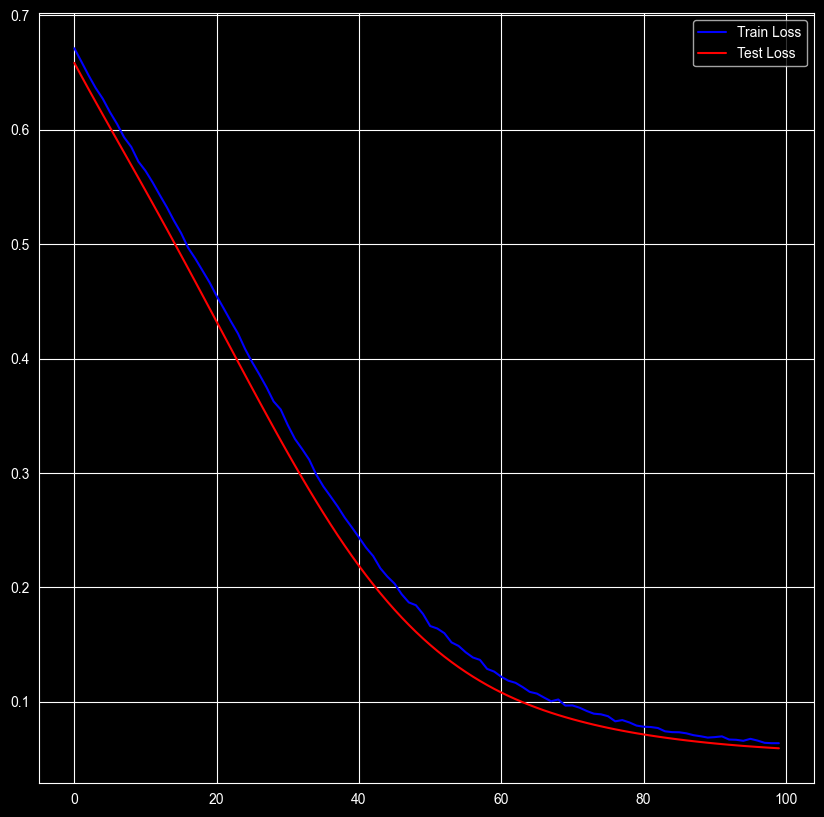

In [101]:
epochs_range = range(len(train_loss))
plt.figure(figsize = (10,10))
# Loss
plt.plot(epochs_range, train_loss, label='Train Loss', color='blue')
plt.plot(epochs_range, test_losss, label='Test Loss', color='red')
plt.legend()

plt.show()

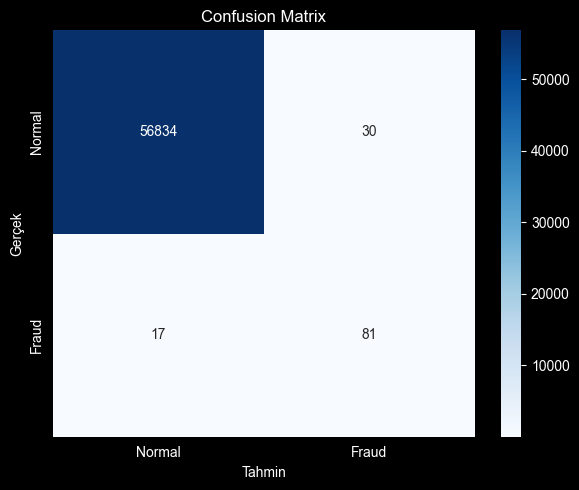

In [109]:
from torchmetrics.classification import BinaryConfusionMatrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_metric = BinaryConfusionMatrix().to(device)

model.eval()
with torch.inference_mode():
    test_logits = model(X_test)
    test_preds = (torch.sigmoid(test_logits) > 0.5).long()
    cm = cm_metric(test_preds, y_test)

cm_np = cm.cpu().numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [102]:
torch.save(model.state_dict(), 'fraud_classifier.pth')